# Titanic - Clasificación de Supervivencia

## Objetivo

El objetivo de este trabajo es construir modelos de clasificación capaces de predecir si un pasajero del Titanic sobrevivió o no.

La variable objetivo es `Survived`, donde:

- 0 = No sobrevivió
- 1 = Sobrevivió

Se compararán dos clasificadores utilizando las mismas variables, preparación de datos, partición de entrenamiento/validación y semilla.

In [69]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [70]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

train.head()

Train: (891, 12)
Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [71]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [72]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Variables utilizadas

Se utilizarán las siguientes variables predictoras:

- `Pclass`: clase del pasajero.
- `Sex`: sexo del pasajero.
- `Age`: edad.
- `SibSp`: cantidad de hermanos o cónyuges a bordo.
- `Parch`: cantidad de padres o hijos a bordo.
- `Fare`: tarifa pagada.
- `Embarked`: puerto de embarque.

Se excluyen `PassengerId`, `Name`, `Ticket` y `Cabin` para trabajar con un conjunto de variables simple y reproducible.

In [73]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = train[features]
y = train["Survived"]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Variable objetivo:
Survived


In [74]:
SEED = 42

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de validación:", X_val.shape)

Datos de entrenamiento: (712, 7)
Datos de validación: (179, 7)


## Partición de datos

Se utilizará un 80% de los datos para entrenamiento y un 20% para validación.

Se utiliza `random_state=42` para garantizar reproducibilidad y `stratify=y` para mantener una proporción similar de las clases.

La misma partición será utilizada por los dos modelos.

In [75]:
X_train = pd.get_dummies(
    X_train,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X_val = pd.get_dummies(
    X_val,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

print(X_train.head())

     Pclass   Age  SibSp  Parch      Fare  Sex_male  Embarked_Q  Embarked_S
692       3   NaN      0      0   56.4958      True       False        True
481       2   NaN      0      0    0.0000      True       False        True
527       1   NaN      0      0  221.7792      True       False        True
855       3  18.0      0      1    9.3500     False       False        True
801       2  31.0      1      1   26.2500     False       False        True


In [76]:
# Calcular las medianas utilizando solamente el conjunto de entrenamiento
age_median = X_train["Age"].median()
fare_median = X_train["Fare"].median()

# Aplicar las medianas
X_train["Age"] = X_train["Age"].fillna(age_median)
X_val["Age"] = X_val["Age"].fillna(age_median)

X_train["Fare"] = X_train["Fare"].fillna(fare_median)
X_val["Fare"] = X_val["Fare"].fillna(fare_median)

print("Valores faltantes en entrenamiento:")
print(X_train.isnull().sum())

print("\nValores faltantes en validación:")
print(X_val.isnull().sum())

Valores faltantes en entrenamiento:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Valores faltantes en validación:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


## Preparación de datos

Los valores faltantes de `Age` y `Fare` se imputan utilizando la mediana calculada sobre el conjunto de entrenamiento.

Las variables categóricas `Sex` y `Embarked` se transforman mediante variables dummy.

La misma preparación se aplica al conjunto de validación y posteriormente al conjunto de prueba de Kaggle.

In [77]:
modelo_logistico = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(
        random_state=SEED,
        max_iter=1000
    ))
])

modelo_logistico.fit(X_train, y_train)

pred_logistico = modelo_logistico.predict(X_val)

In [78]:
accuracy_log = accuracy_score(y_val, pred_logistico)
precision_log = precision_score(y_val, pred_logistico)
recall_log = recall_score(y_val, pred_logistico)
f1_log = f1_score(y_val, pred_logistico)

print("REGRESIÓN LOGÍSTICA")
print("-------------------")
print("Accuracy :", accuracy_log)
print("Precision:", precision_log)
print("Recall   :", recall_log)
print("F1       :", f1_log)

REGRESIÓN LOGÍSTICA
-------------------
Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1       : 0.7244094488188977


In [79]:
cm_log = confusion_matrix(y_val, pred_logistico)

print("Matriz de confusión - Regresión Logística")
print(cm_log)

Matriz de confusión - Regresión Logística
[[98 12]
 [23 46]]


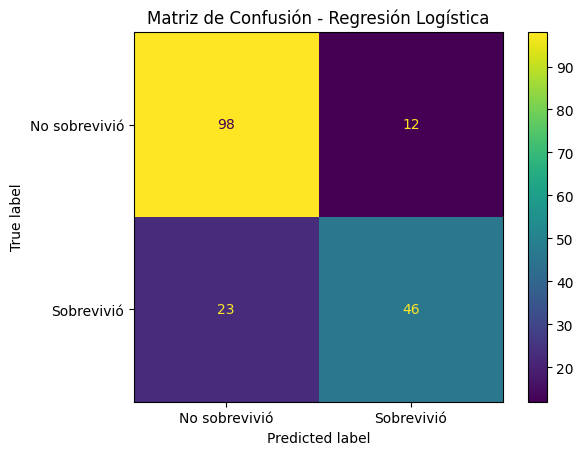

In [80]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["No sobrevivió", "Sobrevivió"]
).plot()

plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

## Interpretación de la matriz de confusión

La matriz evalúa el desempeño del modelo sobre el conjunto de validación ($179$ casos):

* **Verdaderos Negativos (TN = 98):** Pasajeros fallecidos que el modelo clasificó correctamente como no sobrevivientes.
* **Falsos Positivos (FP = 12):** Pasajeros que no sobrevivieron, pero el modelo predijo erróneamente que sobrevivirían (Error Tipo I).
* **Falsos Negativos (FN = 23):** Pasajeros que sí sobrevivieron, pero el modelo clasificó erróneamente como no sobrevivientes (Error Tipo II).
* **Verdaderos Positivos (TP = 46):** Pasajeros sobrevivientes que el modelo identificó correctamente.

**Análisis de error:** El modelo presenta una alta precisión al detectar fallecidos (bajo valor de FP), pero muestra mayor dificultad para detectar sobrevivientes reales, generando $23$ falsos negativos que penalizan su *Recall* ($66.67\%$).

In [81]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_val)

In [82]:
accuracy_rf = accuracy_score(y_val, pred_rf)
precision_rf = precision_score(y_val, pred_rf)
recall_rf = recall_score(y_val, pred_rf)
f1_rf = f1_score(y_val, pred_rf)

print("RANDOM FOREST")
print("-------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1       :", f1_rf)

RANDOM FOREST
-------------
Accuracy : 0.8156424581005587
Precision: 0.78125
Recall   : 0.7246376811594203
F1       : 0.7518796992481203


In [83]:
cm_rf = confusion_matrix(y_val, pred_rf)

print("Matriz de confusión - Random Forest")
print(cm_rf)

Matriz de confusión - Random Forest
[[96 14]
 [19 50]]


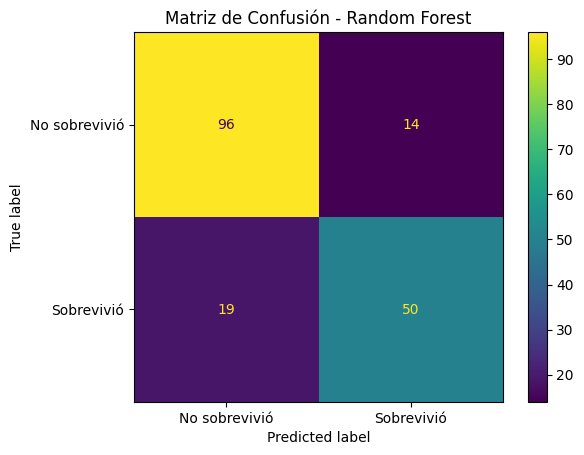

In [84]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No sobrevivió", "Sobrevivió"]
).plot()

plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [85]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_rf
    ],
    "Precision": [
        precision_log,
        precision_rf
    ],
    "Recall": [
        recall_log,
        recall_rf
    ],
    "F1": [
        f1_log,
        f1_rf
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1
0,Regresión Logística,0.804469,0.793103,0.666667,0.724409
1,Random Forest,0.815642,0.781250,0.724638,0.751880


## Comparación de modelos

Para la evaluación local se utilizó una partición estratificada del $80\%$ para entrenamiento y $20\%$ para validación, garantizando la misma proporción de clases en ambos subconjuntos. El modelo de Random Forest superó a la Regresión Logística en casi todas las métricas clave, alcanzando un Accuracy de $81.56\%$ (frente a $80.45\%$), un Recall de $72.46\%$ (frente a $66.67\%$) y un F1-Score de $75.19\%$ (frente a $72.44\%$).Aunque la Regresión Logística presentó una Precision ligeramente superior ($79.31\%$ vs. $78.13\%$), esto responde a un comportamiento más conservador que clasifica menos pasajeros como sobrevivientes. Se selecciona Random Forest como el mejor modelo debido a que su F1-Score demuestra un equilibrio óptimo entre precisión y sensibilidad, capturando interacciones complejas no lineales entre las variables (como la combinación de sexo, clase y tarifa) que la frontera de decisión lineal de la regresión logística no logra representar por completo.

In [86]:
X_test = test[features]

X_test = pd.get_dummies(
    X_test,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test["Age"] = X_test["Age"].fillna(age_median)
X_test["Fare"] = X_test["Fare"].fillna(fare_median)

print(X_test.head())
print("\nValores faltantes:")
print(X_test.isnull().sum())

   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  34.5      0      0   7.8292      True        True       False
1       3  47.0      1      0   7.0000     False       False        True
2       2  62.0      0      0   9.6875      True        True       False
3       3  27.0      0      0   8.6625      True       False        True
4       3  22.0      1      1  12.2875     False       False        True

Valores faltantes:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [87]:
if f1_rf > f1_log:
    mejor_modelo = modelo_rf
    nombre_mejor_modelo = "Random Forest"
else:
    mejor_modelo = modelo_logistico
    nombre_mejor_modelo = "Regresión Logística"

print("Modelo seleccionado para Kaggle:", nombre_mejor_modelo)

Modelo seleccionado para Kaggle: Random Forest


In [88]:
pred_test = mejor_modelo.predict(X_test)

print("Cantidad de predicciones:", len(pred_test))
print("Primeras predicciones:", pred_test[:10])

Cantidad de predicciones: 418
Primeras predicciones: [0 0 0 1 0 0 0 0 1 0]


In [89]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": pred_test
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("Archivo submission.csv creado correctamente.")

submission.head()

Archivo submission.csv creado correctamente.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


# Conclusiones

Desempeño Comparativo: Los modelos ensamblados basados en árboles (Random Forest) demuestran una superioridad estructural frente a los modelos lineales (Regresión Logística) al manejar datos tabulares con relaciones no lineales e interacciones multivariable implícitas.

Capacidad de Detección de la Clase Positiva: La reducción del número de Falsos Negativos en Random Forest (de 23 a 19 casos) permitió elevar significativamente el Recall, garantizando una mayor capacidad para identificar correctamente a los pasajeros que efectivamente sobrevivieron.

Consistencia Metodológica: La aplicación de una preparación de datos unificada —imputación de medinas calculadas exclusivamente sobre el conjunto de entrenamiento y transformación dummy homogénea— aseguró que las diferencias obtenidas en las métricas obedezcan de manera estricta al algoritmo de clasificación utilizado y no a fugas de datos (data leakage).

## Limitaciones

Sesgo por Omisión de Feature Engineering: El conjunto de variables se limitó a los predictores numéricos y categóricos básicos. La exclusión o no procesamiento avanzado de atributos como el título honorífico contenido en la columna Name (ej. Mr., Mrs., Master) o la extracción del tamaño de familia unificado (SibSp + Parch) limita el techo del rendimiento de ambos algoritmos.

Varianza de Validación Única: Se empleó una partición única (Hold-out 80/20). Aunque se mantuvo la estratificación mediante stratify=y, los resultados locales pueden presentar cierta sensibilidad al muestreo. Implementar validación cruzada (K-Fold Cross-Validation) ofrecería estimaciones más robustas y con intervalos de confianza de los parámetros.

Discrepancia de Distribución (Validación Local vs. Kaggle): El desempeño reportado en el entorno local evalúa un subconjunto de train.csv. El puntaje definitivo obtenido en el Public Leaderboard de Kaggle evalúa sobre test.csv, un conjunto cuyos datos no están etiquetados y cuya distribución subyacente puede diferir sutilmente, introduciendo variaciones por sesgo de generalización.

## Declaración de uso de IA

Utilicé herramientas de Inteligencia Artificial (ChatGPT y Gemini) como asistentes de apoyo para las siguientes tareas:

ChatGPT: Se utilizó para proponer y explicar la estructura inicial del código en el notebook, apoyar en la depuración y guiar el flujo general del trabajo (preparación de datos, entrenamiento, evaluación y generación de predicciones).

Gemini: Se utilizó como soporte técnico para la resolución de errores específicos de entorno de ejecución en Kaggle (como errores de rutas de archivo FileNotFoundError e IndexError), optimización final del pipeline de datos y redacción técnica estructurada para el informe de resultados.